In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, roc_auc_score
from imblearn.over_sampling import SMOTE


C:\ProgramData\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
import os
os.environ["OMP_NUM_THREADS"] = '1'

In [3]:
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']

train = pd.read_csv('C:/Users/zhangyiqing1/adult.data', header=None, names=columns, skipinitialspace=True, na_values='?')
test = pd.read_csv('C:/Users/zhangyiqing1/adult.test', header=None, names=columns, skipinitialspace=True, na_values='?', skiprows=1) # The first line of adult.test needs to be skipped
full_data = pd.concat([train, test])
full_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# 1. Data Cleaning and Preprocessing

## （1）Remove missing and duplicate values

In [4]:
full_data["income"] = full_data["income"].str.replace(".", "", regex=False) # Remove the unnecessary "." from the income labels (e.g., '>50K.' → '>50K')
full_data = full_data.replace("?", pd.NA) # Replace missing values represented by "?" with pandas' NA type

In [5]:
print(full_data.isna().sum().sort_values(ascending=False)) # isplay the number of missing values per column in descending order
print('---------------------------\nTotal number of NaNs: ', full_data.isna().sum().sum(), '\n---------------------------') # Display the total number of missing values across all columns

occupation        2809
workclass         2799
native-country     857
age                  0
fnlwgt               0
education            0
education-num        0
marital-status       0
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
income               0
dtype: int64
---------------------------
Total number of NaNs:  6465 
---------------------------


In [6]:
# Remove duplicate and missing rows to ensure data consistency
full_data = full_data.drop_duplicates() 
full_data = full_data.dropna() 
full_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 45175 entries, 0 to 16280
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45175 non-null  int64 
 1   workclass       45175 non-null  object
 2   fnlwgt          45175 non-null  int64 
 3   education       45175 non-null  object
 4   education-num   45175 non-null  int64 
 5   marital-status  45175 non-null  object
 6   occupation      45175 non-null  object
 7   relationship    45175 non-null  object
 8   race            45175 non-null  object
 9   sex             45175 non-null  object
 10  capital-gain    45175 non-null  int64 
 11  capital-loss    45175 non-null  int64 
 12  hours-per-week  45175 non-null  int64 
 13  native-country  45175 non-null  object
 14  income          45175 non-null  object
dtypes: int64(6), object(9)
memory usage: 5.5+ MB


In [7]:
full_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## （2）Convert categorical target variable into binary form (0 and 1)

In [8]:
# Map income values to numerical labels for classification

full_data['income'] = full_data['income'].map({
    '>50K': 1,
    '<=50K': 0,})
full_data.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


# 2. Feature Engineering

## （1）Remove irrelevant or redundant feature

In [9]:
# Drop 'education' because 'education-num' already provides equivalent numerical information.
# Drop 'fnlwgt' because it represents sample weights used in data collection, not socioeconomic factors affecting income.
full_data = full_data.drop([ 'education','fnlwgt'], axis=1)
full_data.head()


,age,workclass,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,0
1,50,Self-emp-not-inc,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,0
2,38,Private,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,0
3,53,Private,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,0
4,28,Private,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,0


## （2）Apply one-hot encoding to categorical variables

In [10]:
# Convert categorical columns into numeric dummy variables using one-hot encoding (workclass, marital-status, occupation, relationship, race, sex)
# Native-country was excluded from one-hot encoding to avoid high-dimensional sparsity
# Later countries are clustered in native-countries
full_data = pd.get_dummies(full_data, columns=['workclass', 'marital-status', 'occupation', 'relationship', 'race', 'sex'], drop_first=True)
full_data.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,native-country,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,...,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male
0,39,13,2174,0,40,United-States,0,False,False,False,...,True,False,False,False,False,False,False,False,True,True
1,50,13,0,0,13,United-States,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,38,9,0,0,40,United-States,0,False,True,False,...,True,False,False,False,False,False,False,False,True,True
3,53,7,0,0,40,United-States,0,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,28,13,0,0,40,Cuba,0,False,True,False,...,False,False,False,False,True,False,True,False,False,False


## （3）Cluster countries based on aggregated numerical features

In [11]:
# Group data by 'native-country' and calculate the mean of relevant numerical attributes.
# This can be used to identify countries with similar socioeconomic characteristics.
country_grouped = full_data.groupby(by='native-country').agg({
    'age': 'mean',
    'education-num': 'mean',
    'capital-gain': 'mean',
    'capital-loss': 'mean',
    'hours-per-week': 'mean',
    'income': 'mean'  # Proportion of individuals with income > 50K
}).reset_index()
country_grouped.head()

,native-country,age,education-num,capital-gain,capital-loss,hours-per-week,income
0,Cambodia,37.923077,9.384615,751.115385,148.192308,42.192308,0.346154
1,Canada,42.846626,10.742331,1320.588957,146.447853,41.588957,0.368098
2,China,41.460177,11.309735,1519.858407,184.247788,39.115044,0.318584
3,Columbia,39.195122,9.304878,129.951220,67.634146,40.353659,0.048780
4,Cuba,45.887218,9.503759,488.233083,65.075188,40.669173,0.255639


In [12]:
features_to_scale = ['age', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']

# Apply StandardScaler to normalize the features
scaler = StandardScaler()
country_grouped[features_to_scale] = scaler.fit_transform(country_grouped[features_to_scale])

country_grouped.head()

,native-country,age,education-num,capital-gain,capital-loss,hours-per-week,income
0,Cambodia,-0.267949,-0.245945,0.046818,0.043328,0.648935,0.995936
1,Canada,1.027680,0.584971,0.871197,0.038085,0.393378,1.159762
2,China,0.662837,0.932220,1.159663,0.151694,-0.654480,0.790112
3,Columbia,0.066789,-0.294744,-0.852389,-0.198790,-0.129849,-1.224119
4,Cuba,1.827811,-0.173029,-0.333735,-0.206481,0.003791,0.320194


C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Window

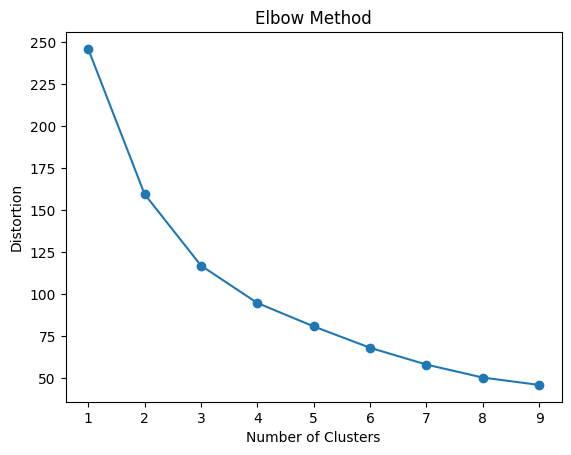

<Figure size 640x480 with 0 Axes>

In [13]:
# Find optimal number of clusters using the Elbow Method

distortions = []
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(country_grouped[features_to_scale])
    distortions.append(kmeans.inertia_)

plt.plot(range(1, 10), distortions, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()
plt.tight_layout()

In [14]:
# Apply K-means clustering with 3 clusters
kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
country_grouped['Cluster'] = kmeans.fit_predict(country_grouped[features_to_scale])

# Display the clusters
country_grouped[['native-country', 'Cluster']].head()

C:\ProgramData\anaconda3\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


,native-country,Cluster
0,Cambodia,1
1,Canada,1
2,China,1
3,Columbia,0
4,Cuba,1


In [15]:
# Create a mapping from native-country to cluster
country_cluster_map = country_grouped.set_index('native-country')['Cluster'].to_dict()

# Add the cluster information to the original dataset
full_data['country-cluster'] = full_data['native-country'].map(country_cluster_map)

# Check the result
full_data = full_data.drop(['native-country'], axis=1)
full_data.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,income,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,country-cluster
0,39,13,2174,0,40,0,False,False,False,False,...,False,False,False,False,False,False,False,True,True,1
1,50,13,0,0,13,0,False,False,False,True,...,False,False,False,False,False,False,False,True,True,1
2,38,9,0,0,40,0,False,True,False,False,...,False,False,False,False,False,False,False,True,True,1
3,53,7,0,0,40,0,False,True,False,False,...,False,False,False,False,False,True,False,False,True,1
4,28,13,0,0,40,0,False,True,False,False,...,False,False,False,True,False,True,False,False,False,1


## （3）Handle imbalanced data problem

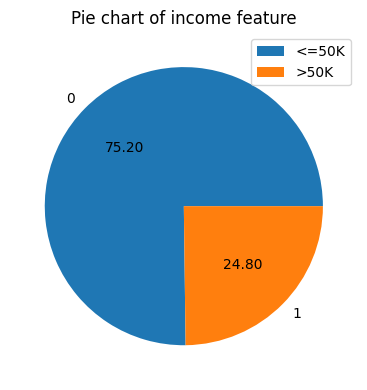

In [16]:
# Visualize the class imbalance: the proportion of individuals with income >50K is much smaller.
plt.figure(figsize=(6, 4))
plt.pie(x=full_data['income'].value_counts().values, labels=full_data['income'].value_counts().index, autopct='%.2f')
plt.title('Pie chart of income feature')
plt.tight_layout()
plt.legend(['<=50K', '>50K'])
plt.show()

In [17]:
X = full_data.drop('income', axis=1)
y = full_data['income']

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print(f"Original dataset shape: {X.shape}, {y.shape}")
print(f"Resampled dataset shape: {X_resampled.shape}, {y_resampled.shape}")

Original dataset shape: (45175, 41), (45175,)
Resampled dataset shape: (67946, 41), (67946,)


In [18]:
# Combine the features and target back into one DataFrame
full_data = pd.concat([X_resampled, y_resampled], axis=1)


print(f"Resampled DataFrame shape: {full_data.shape}")

full_data.head()

Resampled DataFrame shape: (67946, 42)


,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,country-cluster,income
0,39,13,2174,0,40,False,False,False,False,True,...,False,False,False,False,False,False,True,True,1,0
1,50,13,0,0,13,False,False,False,True,False,...,False,False,False,False,False,False,True,True,1,0
2,38,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,True,True,1,0
3,53,7,0,0,40,False,True,False,False,False,...,False,False,False,False,True,False,False,True,1,0
4,28,13,0,0,40,False,True,False,False,False,...,False,False,True,False,True,False,False,False,1,0


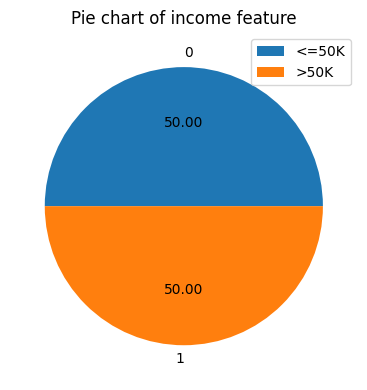

In [19]:
plt.figure(figsize=(6, 4))
plt.pie(x=full_data['income'].value_counts().values, labels=full_data['income'].value_counts().index, autopct='%.2f')
plt.title('Pie chart of income feature')
plt.tight_layout()
plt.legend(['<=50K', '>50K'])
plt.show()

In [20]:
# Verify that there are no missing values remaining
full_data.isna().sum() 

age                                     0
education-num                           0
capital-gain                            0
capital-loss                            0
hours-per-week                          0
workclass_Local-gov                     0
workclass_Private                       0
workclass_Self-emp-inc                  0
workclass_Self-emp-not-inc              0
workclass_State-gov                     0
workclass_Without-pay                   0
marital-status_Married-AF-spouse        0
marital-status_Married-civ-spouse       0
marital-status_Married-spouse-absent    0
marital-status_Never-married            0
marital-status_Separated                0
marital-status_Widowed                  0
occupation_Armed-Forces                 0
occupation_Craft-repair                 0
occupation_Exec-managerial              0
occupation_Farming-fishing              0
occupation_Handlers-cleaners            0
occupation_Machine-op-inspct            0
occupation_Other-service          

# 3. Model evaluation 

## （1）Split the data into training and test sets

In [21]:
train, test = train_test_split(full_data, random_state=42, test_size=0.3, shuffle=True)
print('Train shape: ', train.shape)
print('Test shape: ', test.shape)

Train shape:  (47562, 42)
Test shape:  (20384, 42)


In [22]:
X_train = train.drop(['income'], axis=1)
y_train = train['income']

X_test = test.drop(['income'], axis=1)
y_test = test['income']

X_train_rf = train.drop(['income'], axis=1)
y_train_rf = train['income']

X_test_rf = test.drop(['income'], axis=1)
y_test_rf = test['income']


## （2）Data standardization

In [23]:
for col in ['capital-gain', 'capital-loss']:
    X_train[col] = np.log1p(X_train[col])  
    X_test[col] = np.log1p(X_test[col])

In [24]:
scale_cols = ['age', 'education-num', 'hours-per-week', 'capital-gain', 'capital-loss']
scaler = StandardScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])

In [25]:
X_train.head()

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,workclass_State-gov,...,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,race_Asian-Pac-Islander,race_Black,race_Other,race_White,sex_Male,country-cluster
38429,-1.854160,-1.002329,-0.382392,-0.259786,-1.919790,False,True,False,False,False,...,False,True,False,False,False,False,False,True,False,1
25155,-1.137488,0.182794,-0.382392,-0.259786,0.641823,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,1
6267,-0.420817,-0.212247,2.319564,-0.259786,-0.638983,False,True,False,False,False,...,False,False,False,False,False,False,False,True,True,1
2816,-1.615269,-0.212247,-0.382392,-0.259786,-1.065919,False,True,False,False,False,...,False,True,False,False,False,False,False,True,True,1
61767,2.605130,-2.187452,-0.382392,-0.259786,-1.065919,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,1


## （3）Logistic Regression

In [26]:
log_model = LogisticRegression(max_iter=1000)
start_train = time.time()
log_model.fit(X_train, y_train)
end_train = time.time()

start_pred = time.time()
y_pred_log = log_model.predict(X_test)
end_pred = time.time()

log_train_time = end_train - start_train
log_pred_time = end_pred - start_pred

print(f"Training time: {log_train_time:.4f} seconds")
print(f"Prediction time: {log_pred_time:.4f} seconds\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))
print("Logistic Regression accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))


Training time: 1.4415 seconds
Prediction time: 0.0108 seconds

Confusion Matrix:
[[8529 1639]
 [1366 8850]]
Logistic Regression accuracy: 0.8525804552590267
              precision    recall  f1-score   support

           0       0.86      0.84      0.85     10168
           1       0.84      0.87      0.85     10216

    accuracy                           0.85     20384
   macro avg       0.85      0.85      0.85     20384
weighted avg       0.85      0.85      0.85     20384



In [27]:
# I tried the SVM model, but it becomes extremely time-consuming when the sample data volume is too large, while the accuracy isn't very high.

'''
svm_model = SVC()
start_train = time.time()
svm_model.fit(X_train, y_train)
end_train = time.time()

start_pred = time.time()
y_pred_svm = svm_model.predict(X_test)
end_pred = time.time()

svm_train_time = end_train - start_train
svm_pred_time = end_pred - start_pred

print(f"Training time: {svm_train_time:.4f} seconds")
print(f"Prediction time: {svm_pred_time:.4f} seconds\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_svm))
print("SVM accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))
'''

'\nsvm_model = SVC()\nstart_train = time.time()\nsvm_model.fit(X_train, y_train)\nend_train = time.time()\n\nstart_pred = time.time()\ny_pred_svm = svm_model.predict(X_test)\nend_pred = time.time()\n\nsvm_train_time = end_train - start_train\nsvm_pred_time = end_pred - start_pred\n\nprint(f"Training time: {svm_train_time:.4f} seconds")\nprint(f"Prediction time: {svm_pred_time:.4f} seconds\n")\nprint("Confusion Matrix:")\nprint(confusion_matrix(y_test, y_pred_svm))\nprint("SVM accuracy:", accuracy_score(y_test, y_pred_svm))\nprint(classification_report(y_test, y_pred_svm))\n'

## （4）Random Forest

In [32]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
start_train = time.time()
rf_model.fit(X_train_rf, y_train_rf)
end_train = time.time()

start_pred = time.time()
y_pred_rf = rf_model.predict(X_test_rf)
end_pred = time.time()

rf_train_time = end_train - start_train
rf_pred_time = end_pred - start_pred

print(f"Training time: {rf_train_time:.4f} seconds")
print(f"Prediction time: {rf_pred_time:.4f} seconds\n")
print("Confusion Matrix:")
print(confusion_matrix(y_test_rf, y_pred_rf))
print("Random Forest accuracy:", accuracy_score(y_test_rf, y_pred_rf))
print(classification_report(y_test_rf, y_pred_rf))

Training time: 6.7428 seconds
Prediction time: 0.5213 seconds

Confusion Matrix:
[[8846 1322]
 [1033 9183]]
SVM accuracy: 0.8844682103610675
              precision    recall  f1-score   support

           0       0.90      0.87      0.88     10168
           1       0.87      0.90      0.89     10216

    accuracy                           0.88     20384
   macro avg       0.88      0.88      0.88     20384
weighted avg       0.88      0.88      0.88     20384



## （4）Model performance comparison

In [38]:
model_results = []
model_results.append(["Random Forest",
                      accuracy_score(y_test_rf, y_pred_rf),
                      precision_score(y_test_rf, y_pred_rf), 
                      recall_score(y_test_rf, y_pred_rf),
                      f1_score(y_test_rf, y_pred_rf)])
model_results.append(["Logistic Regression",
                      accuracy_score(y_test, y_pred_log),
                      precision_score(y_test, y_pred_log), 
                      recall_score(y_test, y_pred_log),
                      f1_score(y_test, y_pred_log)])
scores_df = pd.DataFrame(model_results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score"])
scores_df

,Model,Accuracy,Precision,Recall,F1-Score
0,Random Forest,0.884468,0.874155,0.898884,0.886347
1,Logistic Regression,0.852580,0.843741,0.866288,0.854866


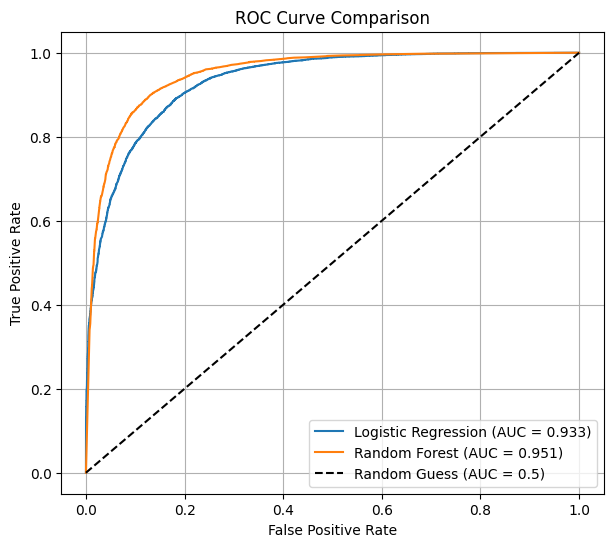

In [34]:
# Compute predicted probabilities for the positive class (income = 1)
y_proba_log = log_model.predict_proba(X_test)[:, 1]
y_proba_rf  = rf_model.predict_proba(X_test_rf)[:, 1]

# Compute ROC coordinates and AUC scores for both models
fpr_log, tpr_log, _ = roc_curve(y_test, y_proba_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test_rf, y_proba_rf)

auc_log = roc_auc_score(y_test, y_proba_log)
auc_rf  = roc_auc_score(y_test_rf, y_proba_rf)

# Plot ROC curves
plt.figure(figsize=(7,6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.3f})')
plt.plot([0,1], [0,1], 'k--', label='Random Guess (AUC = 0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()